# Week 6 · Notebook 3 — Parameter Tuning, Parameter Control and Hyper-Heuristics

**Goals**
- Use the Eiben–Hinterding–Michalewicz (1999) taxonomy — *tuning* (offline) vs *control* (online: deterministic,
  adaptive, self-adaptive) — and implement one representative of each.
- Self-adaptive step sizes in evolution strategies (Schwefel's log-normal rule): validate the log-normal moments,
  the $(1,\lambda)$ stagnation distance predicted by the progress coefficient $c_{1,\lambda}$, and scale invariance.
- Adaptive operator selection (AOS) with bandits: probability matching, adaptive pursuit, sliding-window UCB —
  validated against their stationary laws and the UCB1 regret bound (Auer et al. 2002).
- Offline tuning by racing: F-Race (Birattari et al. 2002) with a from-scratch Friedman test validated against
  `scipy.stats.friedmanchisquare`; the idea of iterated racing (irace).
- Selection hyper-heuristics choosing low-level heuristics for bin packing.

**Prerequisites:** Notebooks 1–2 (ask–tell loop, DE, $(1+1)$-ES); basic nonparametric statistics (ranks).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import random
from utils import BENCHMARKS, shifted_rotated, random_rotation, ellipsoid, PALETTE
from scipy import stats, integrate

## 1. Taxonomy

Eiben, Hinterding & Michalewicz (1999, *IEEE TEC* 3(2)) distinguish **parameter tuning** — fix good values *before* the
run (by hand, by design of experiments, by racing or by an optimiser) — from **parameter control** — change values
*during* the run. Control is further classified by *how* the change is decided:

| type | mechanism | examples in this course |
|---|---|---|
| deterministic | a schedule of time/evaluations, no feedback | SA cooling $T_k=T_0\alpha^k$; GA mutation rate decreasing in $t$ |
| adaptive | feedback from the search updates the parameter by an *external* rule | 1/5th success rule; JADE's $\mu_F,\mu_{CR}$; CMA-ES's CSA; reactive tabu tenure (Battiti & Tecchiolli 1994) |
| self-adaptive | the parameter is *encoded in the individual* and evolves with it, selected only indirectly | Schwefel's $\sigma$-self-adaptation; self-adaptive mutation rates in GAs (Bäck 1992) |

Karafotias, Hoogendoorn & Eiben (2015, *IEEE TEC* 19(2)) review two decades of control methods. The practical question
is always the same: the best parameter value is **state-dependent**, so a static value found by tuning is at best
the best *compromise*.

## 2. Deterministic vs self-adaptive step-size control

In a $(1,\lambda)$-$\sigma$SA-ES each offspring first mutates its own step size log-normally, then its position:

$$
\sigma_k = \sigma\,e^{\tau\,\xi_k},\quad \xi_k\sim\mathcal{N}(0,1),\qquad y_k = x + \sigma_k z_k,\quad z_k\sim\mathcal{N}(0,I),
$$

and the best offspring passes on **both** $y_k$ and $\sigma_k$ (Schwefel 1977). The learning rate is chosen
$\tau\propto1/\sqrt{d}$; we use $\tau=1/\sqrt{2d}$ (cf. Beyer & Schwefel 2002, *Natural Computing* 1). The log-normal rule is unbiased on the log scale: $\mathbb{E}[\ln\sigma_k]=\ln\sigma$,
median $\sigma$, $\mathbb{E}[\sigma_k]=\sigma e^{\tau^2/2}$, so up- and down-scalings by the same factor are equally likely.

**Stagnation of constant $\sigma$.** For $d\to\infty$ the normalised progress of the $(1,\lambda)$-ES on the sphere is
$\varphi^{\ast} = c_{1,\lambda}\sigma^{\ast} - \sigma^{\ast2}/2$ with $\sigma^{\ast}=\sigma d/R$ and the *progress coefficient*
$c_{1,\lambda}=\mathbb{E}[\max_{k\le\lambda}\xi_k]$ (Beyer 2001). A constant $\sigma$ therefore makes progress only
while $\sigma^{\ast}\lt2c_{1,\lambda}$ and fluctuates around the **stationary distance** $R_\infty = \sigma d/(2c_{1,\lambda})$.

In [2]:
lam = 10
c1lam = integrate.quad(lambda x: x * lam * stats.norm.pdf(x) * stats.norm.cdf(x) ** (lam - 1), -np.inf, np.inf)[0]
check_close(c1lam, 1.5388, "progress coefficient c_{1,10} (Beyer 2001 table: 1.539)", atol=1e-3)

# log-normal moments
tau, sig = 1 / np.sqrt(20), 2.0
s_new = sig * np.exp(tau * rng.standard_normal(400000))
check_close([np.log(s_new).mean(), np.median(s_new), s_new.mean()], [np.log(sig), sig, sig * np.exp(tau**2 / 2)],
            "log-normal mutation: E[ln s'], median s', E[s']", atol=4e-3)

def comma_es(d, R0, T, seed, sigma0, mode="constant", gamma=None, lam=10):
    """(1,lambda)-ES on the sphere started at distance R0. mode: 'constant', 'deterministic'
    (sigma_t = sigma0 * gamma^t) or 'self-adaptive' (log-normal, tau = 1/sqrt(2d)).
    Returns per-generation (R, sigma)."""
    r = np.random.default_rng(seed)
    x = np.zeros(d); x[0] = R0; s = sigma0; tau = 1 / np.sqrt(2 * d); out = []
    for t in range(T):
        if mode == "self-adaptive":
            S = s * np.exp(tau * r.standard_normal(lam))
        elif mode == "deterministic":
            S = np.full(lam, sigma0 * gamma**t)
        else:
            S = np.full(lam, s)
        Y = x + S[:, None] * r.standard_normal((lam, d))
        f = (Y**2).sum(1); j = np.argmin(f)
        x, s = Y[j], S[j]
        out.append((np.sqrt(f[j]), s))
    return np.array(out)

d_big = 100
o = comma_es(d_big, 1.0, 5000, 0, 0.01)
R_stat = np.median(o[2500:, 0])
check_close(R_stat, 0.01 * d_big / (2 * c1lam), f"constant sigma, d={d_big}: stationary distance vs sigma d/(2 c_1,10)", rtol=0.05)

[PASS] progress coefficient c_{1,10} (Beyer 2001 table: 1.539): got 1.538753, expected 1.5388
[PASS] log-normal mutation: E[ln s'], median s', E[s']: got [0.693182 1.999883 2.050826], expected [0.693147 2.       2.05063 ]


[PASS] constant sigma, d=100: stationary distance vs sigma d/(2 c_1,10): got 0.324026, expected 0.324938


Now compare the three kinds of control on the 10-D sphere, starting at $R_0=1$ and at $R_0=1000$. The deterministic
schedule $\sigma_t=\sigma_0\gamma^t$ is *tuned* for $R_0=1$ ($\sigma_0=0.1R_0$ and $\gamma$ equal to the rate that
self-adaptation achieves); at $R_0=1000$ it is re-used unchanged ($\sigma_0=0.1$): the schedule has the right *shape*
but no feedback about the scale. Self-adaptation should give the **same** linear rate from both starting points (scale invariance).

self-adaptive log-R slope per generation: R0=1: -0.0758, R0=1000: -0.0754  -> tuned gamma = 0.9270
[PASS] self-adaptation: same linear rate from R0=1 and R0=1000 (scale invariance): got -0.075406, expected -0.075781
normalised step sigma* under self-adaptation: median 2.38, IQR 1.82-3.03 (zero-progress bound 2 c_1,10 = 3.08)
[PASS] self-adaptive sigma* stays inside the progress region (< 2 c_1,lambda) 75% of the time


constant       R0=     1: final distance median 3.49e-01
deterministic  R0=     1: final distance median 1.77e-50
self-adaptive  R0=     1: final distance median 4.88e-50
constant       R0=  1000: final distance median 3.49e+02
deterministic  R0=  1000: final distance median 9.98e+02
self-adaptive  R0=  1000: final distance median 1.18e-47
[PASS] deterministic schedule tuned for R0=1 fails to transfer to R0=1000


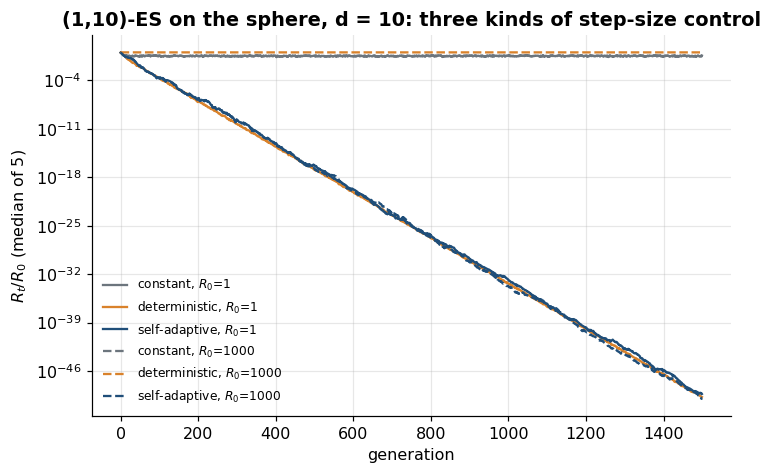

In [3]:
d, G = 10, 1500
sa_runs = {R0: [comma_es(d, R0, G, s, 0.1 * R0, "self-adaptive") for s in range(5)] for R0 in [1.0, 1e3]}
slopes = {R0: np.median([stats.linregress(np.arange(200, G), np.log(o_[200:, 0])).slope for o_ in runs])
          for R0, runs in sa_runs.items()}
gamma = np.exp(slopes[1.0])
print(f"self-adaptive log-R slope per generation: R0=1: {slopes[1.0]:.4f}, R0=1000: {slopes[1e3]:.4f}  -> tuned gamma = {gamma:.4f}")
check_close(slopes[1e3], slopes[1.0], "self-adaptation: same linear rate from R0=1 and R0=1000 (scale invariance)", rtol=0.05)
sig_star = np.concatenate([o_[200:, 1] * d / o_[200:, 0] for o_ in sa_runs[1.0]])
print(f"normalised step sigma* under self-adaptation: median {np.median(sig_star):.2f}, IQR {np.percentile(sig_star, 25):.2f}-{np.percentile(sig_star, 75):.2f} "
      f"(zero-progress bound 2 c_1,10 = {2 * c1lam:.2f})")
check_true(np.percentile(sig_star, 75) < 2 * c1lam, "self-adaptive sigma* stays inside the progress region (< 2 c_1,lambda) 75% of the time")

runs_all = {}
for R0 in [1.0, 1e3]:
    runs_all["constant", R0] = [comma_es(d, R0, G, s, 0.1 * R0, "constant") for s in range(5)]
    runs_all["deterministic", R0] = [comma_es(d, R0, G, s, 0.1, "deterministic", gamma=gamma) for s in range(5)]
    runs_all["self-adaptive", R0] = sa_runs[R0]
for (mode, R0), rs in runs_all.items():
    print(f"{mode:14s} R0={R0:6.0f}: final distance median {np.median([o_[-1, 0] for o_ in rs]):.2e}")
check_true(np.median([o_[-1, 0] for o_ in runs_all["deterministic", 1e3]]) > 1e3 * np.median([o_[-1, 0] for o_ in runs_all["deterministic", 1.0]]),
           "deterministic schedule tuned for R0=1 fails to transfer to R0=1000")

fig, ax = plt.subplots()
cols = {"constant": PALETTE["grey"], "deterministic": PALETTE["orange"], "self-adaptive": PALETTE["blue"]}
for (mode, R0), rs in runs_all.items():
    ax.semilogy(np.median([o_[:, 0] / R0 for o_ in rs], 0), color=cols[mode], ls="-" if R0 == 1 else "--",
                label=f"{mode}, $R_0$={R0:g}")
ax.set(xlabel="generation", ylabel="$R_t/R_0$ (median of 5)", title="(1,10)-ES on the sphere, d = 10: three kinds of step-size control")
ax.legend(fontsize=8); savefig("w6_step_size_control.png"); plt.show()

The deterministic schedule is exactly as good as self-adaptation when its assumptions hold ($R_0=1$) and useless
when they do not ($\sigma_0$ is 1000 times too small for $R_0=1000$ and shrinks at the tuned rate, so the search freezes).
Constant $\sigma$ stagnates at $R_\infty$. Only feedback-based control is robust to the unknown scale.

## 3. Adaptive operator selection with multi-armed bandits

AOS treats $K$ variation operators as arms of a bandit: at every step choose an operator, observe a *reward*
(credit assignment, here the relative fitness improvement $\max(0,(f_{\text{old}}-f_{\text{new}})/f_{\text{old}})$),
update the selection rule (Fialho, Da Costa, Schoenauer & Sebag 2010, *Ann. Math. Artif. Intell.* 60).

- **Probability matching (PM)** (Goldberg 1990): quality $q_i\leftarrow q_i+\alpha(r-q_i)$;
  $p_i = p_{\min} + (1-Kp_{\min})\,q_i/\sum_j q_j$.
- **Adaptive pursuit (AP)** (Thierens 2005): $p_{i^{\ast}}\leftarrow p_{i^{\ast}}+\beta(p_{\max}-p_{i^{\ast}})$ for the
  current best $i^{\ast}=\arg\max q$, others $p_i\leftarrow p_i+\beta(p_{\min}-p_i)$, with $p_{\max}=1-(K-1)p_{\min}$.
- **UCB1** (Auer, Cesa-Bianchi & Fischer 2002): choose $\arg\max_i \hat{\mu}_i + \sqrt{2\ln t/n_i}$; expected regret
  after $T$ steps $\le \sum_{i:\Delta_i\gt0}\frac{8\ln T}{\Delta_i}+\big(1+\frac{\pi^2}{3}\big)\sum_i\Delta_i$. Rewards in
  AOS are **non-stationary**, so we use a *sliding-window* UCB (Garivier & Moulines 2011) over the last $W$ applications
  with rewards normalised by the window maximum (as in Fialho et al.'s extreme/normalised credit).

In [4]:
class FixedOp:
    def __init__(self, K, rng, i): self.K, self.i = K, i
    def select(self): return self.i
    def update(self, i, r): pass

class UniformOp:
    def __init__(self, K, rng): self.K, self.rng = K, rng
    def select(self): return int(self.rng.integers(self.K))
    def update(self, i, r): pass

class ProbabilityMatching:
    def __init__(self, K, rng, p_min=0.02, alpha=0.3):
        self.K, self.rng, self.p_min, self.alpha, self.q = K, rng, p_min, alpha, np.ones(K)
    def probs(self):
        return self.p_min + (1 - self.K * self.p_min) * self.q / self.q.sum() if self.q.sum() > 0 else np.full(self.K, 1 / self.K)
    def select(self): return int(self.rng.choice(self.K, p=self.probs()))
    def update(self, i, r): self.q[i] += self.alpha * (r - self.q[i])

class AdaptivePursuit(ProbabilityMatching):
    def __init__(self, K, rng, p_min=0.02, alpha=0.3, beta=0.3):
        super().__init__(K, rng, p_min, alpha); self.beta, self.p = beta, np.full(K, 1 / K)
    def probs(self): return self.p
    def update(self, i, r):
        self.q[i] += self.alpha * (r - self.q[i])
        target = np.full(self.K, self.p_min); target[np.argmax(self.q)] = 1 - (self.K - 1) * self.p_min
        self.p += self.beta * (target - self.p)

class UCB1:
    def __init__(self, K, rng): self.K, self.n, self.s, self.t = K, np.zeros(K), np.zeros(K), 0
    def select(self):
        if self.t < self.K: return self.t
        return int(np.argmax(self.s / self.n + np.sqrt(2 * np.log(self.t) / self.n)))
    def update(self, i, r): self.n[i] += 1; self.s[i] += r; self.t += 1

class SlidingWindowUCB:
    def __init__(self, K, rng, W=100, C=0.5):
        self.K, self.rng, self.W, self.C = K, rng, W, C
        self.ops, self.rs, self.t = np.full(W, -1), np.zeros(W), 0
    def select(self):
        m = self.ops >= 0
        n = np.bincount(self.ops[m], minlength=self.K).astype(float)
        s = np.bincount(self.ops[m], weights=self.rs[m], minlength=self.K)
        if (n == 0).any():
            z = np.flatnonzero(n == 0); return int(z[self.rng.integers(len(z))])
        scale = max(1e-12, self.rs[m].max())
        return int(np.argmax(s / n / scale + self.C * np.sqrt(2 * np.log(n.sum()) / n)))
    def update(self, i, r):
        self.ops[self.t % self.W], self.rs[self.t % self.W] = i, r; self.t += 1

### Validation on stationary bandits
(i) UCB1's empirical regret on a Bernoulli bandit must stay below the Auer et al. bound; (ii) in a stationary
environment AP's probability of the best arm converges to $p_{\max}=1-(K-1)p_{\min}$; (iii) PM's probabilities converge
to $p_{\min}+(1-Kp_{\min})\mu_i/\sum_j\mu_j$ (up to the noise of the exponential average).

In [5]:
mu_arms = np.array([0.9, 0.8, 0.6, 0.5, 0.3])
T_b, runs_b = 5000, 40
regret = np.zeros((runs_b, T_b))
for rep in range(runs_b):
    rb = np.random.default_rng(rep); ucb = UCB1(5, rb); cum = 0.0
    for t in range(T_b):
        i = ucb.select(); ucb.update(i, float(rb.random() < mu_arms[i])); cum += mu_arms[0] - mu_arms[i]; regret[rep, t] = cum
gaps = mu_arms[0] - mu_arms[1:]
bound = lambda T: np.sum(8 * np.log(T) / gaps) + (1 + np.pi**2 / 3) * gaps.sum()
ts_chk = np.array([100, 500, 1000, 5000])
emp = regret.mean(0)[ts_chk - 1]
print("mean regret:", np.round(emp, 1), " Auer bound:", np.round([bound(t) for t in ts_chk], 1))
check_true(np.all(emp < [bound(t) for t in ts_chk]), "UCB1 empirical regret below the Auer-Cesa-Bianchi-Fischer bound")
growth = (emp[3] - emp[2]) / np.log(5)  # regret increase per unit of ln T between T=1000 and 5000
check_true(growth < np.sum(8 / gaps), f"logarithmic growth: d(regret)/d(ln T) = {growth:.1f} < sum 8/Delta = {np.sum(8 / gaps):.0f}")

ap, pm = AdaptivePursuit(5, np.random.default_rng(1)), ProbabilityMatching(5, np.random.default_rng(2), alpha=0.02)
rb = np.random.default_rng(3); pm_hist = []
for t in range(20000):
    for sel in (ap, pm):
        i = sel.select(); sel.update(i, float(rb.random() < mu_arms[i]))
    if t >= 10000: pm_hist.append(pm.probs())
check_close(ap.p[0], 1 - 4 * 0.02, "adaptive pursuit: p(best arm) -> p_max = 1-(K-1)p_min", atol=0.02)
check_close(np.mean(pm_hist, 0), 0.02 + (1 - 5 * 0.02) * mu_arms / mu_arms.sum(),
            "probability matching: p_i -> p_min + (1-K p_min) mu_i / sum mu", atol=0.02)

mean regret: [ 16.9  51.8  77.7 160.3]  Auer bound: [ 650.7  876.1  973.1 1198.4]
[PASS] UCB1 empirical regret below the Auer-Cesa-Bianchi-Fischer bound
[PASS] logarithmic growth: d(regret)/d(ln T) = 51.3 < sum 8/Delta = 140


[PASS] adaptive pursuit: p(best arm) -> p_max = 1-(K-1)p_min: got 0.919991, expected 0.92
[PASS] probability matching: p_i -> p_min + (1-K p_min) mu_i / sum mu: got [0.280108 0.254705 0.191163 0.164168 0.109856], expected [0.28129  0.252258 0.194194 0.165161 0.107097]


### AOS where the best operator changes: step-size operators for a $(1+1)$-ES
Operators $o_k$: Gaussian mutation with fixed step $\sigma_k=10^{-k}$, $k=0,\dots,6$, on the 10-D sphere starting
at $\Vert x\Vert\approx3$. As the search approaches the optimum the useful operator moves from large to small steps
— a textbook non-stationary bandit. No single operator can converge; a good AOS must *track* the best one. The
1/5th rule (continuous adaptive control, Notebook 2) is the reference.

In [6]:
SIG = 10.0 ** -np.arange(7)

def es_with_aos(selector, budget, seed, d=10, record=False):
    r = np.random.default_rng(seed)
    x = r.standard_normal(d); fx = x @ x; used = []
    for t in range(budget - 1):
        i = selector.select(); y = x + SIG[i] * r.standard_normal(d); fy = y @ y
        selector.update(i, max(0.0, (fx - fy) / fx))
        if fy <= fx: x, fx = y, fy
        if record: used.append(i)
    return fx, np.array(used)

def es_one_fifth(budget, seed, d=10):
    r = np.random.default_rng(seed)
    x = r.standard_normal(d); fx = x @ x; s = 1.0
    for t in range(budget - 1):
        y = x + s * r.standard_normal(d); fy = y @ y; ok = fy <= fx
        if ok: x, fx = y, fy
        s *= np.exp((ok - 0.2) / (0.8 * np.sqrt(d + 1)))
    return fx

B_aos, seeds_aos = 3000, 12
selectors = {"best single op (σ=1e-2)": lambda r: FixedOp(7, r, 2), "uniform": lambda r: UniformOp(7, r),
             "PM": lambda r: ProbabilityMatching(7, r), "AP": lambda r: AdaptivePursuit(7, r),
             "SW-UCB": lambda r: SlidingWindowUCB(7, r)}
aos_res = {k: np.log10([es_with_aos(mk(np.random.default_rng(s)), B_aos, s)[0] for s in range(seeds_aos)]) for k, mk in selectors.items()}
single = {k: np.median(np.log10([es_with_aos(FixedOp(7, None, k), B_aos, s)[0] for s in range(4)])) for k in range(7)}
aos_res["1/5th rule"] = np.log10([es_one_fifth(B_aos, s) for s in range(seeds_aos)])
print("single operators, median log10 f:", {f"1e-{k}": round(float(v), 1) for k, v in single.items()})
for k, v in aos_res.items():
    print(f"{k:24s} log10 f: median {np.median(v):7.2f}  IQR [{np.percentile(v, 25):7.2f}, {np.percentile(v, 75):7.2f}]")
for k in ["PM", "AP", "SW-UCB"]:
    p = stats.mannwhitneyu(aos_res[k], aos_res["uniform"], alternative="less").pvalue
    check_true(p < 0.01 and np.median(aos_res[k]) < min(single.values()),
               f"{k} beats uniform selection (one-sided Mann-Whitney p = {p:.1e}) and every single operator")

single operators, median log10 f: {'1e-0': 0.1, '1e-1': -1.8, '1e-2': -3.9, '1e-3': 0.4, '1e-4': 0.9, '1e-5': 0.9, '1e-6': 0.9}
best single op (σ=1e-2)  log10 f: median   -3.88  IQR [  -3.94,   -3.86]
uniform                  log10 f: median   -7.30  IQR [  -7.72,   -6.93]
PM                       log10 f: median  -11.65  IQR [ -11.69,  -11.60]
AP                       log10 f: median  -11.66  IQR [ -11.71,  -11.58]
SW-UCB                   log10 f: median  -11.24  IQR [ -11.39,  -11.09]
1/5th rule               log10 f: median  -39.68  IQR [ -40.66,  -39.26]
[PASS] PM beats uniform selection (one-sided Mann-Whitney p = 1.8e-05) and every single operator
[PASS] AP beats uniform selection (one-sided Mann-Whitney p = 1.8e-05) and every single operator
[PASS] SW-UCB beats uniform selection (one-sided Mann-Whitney p = 1.8e-05) and every single operator


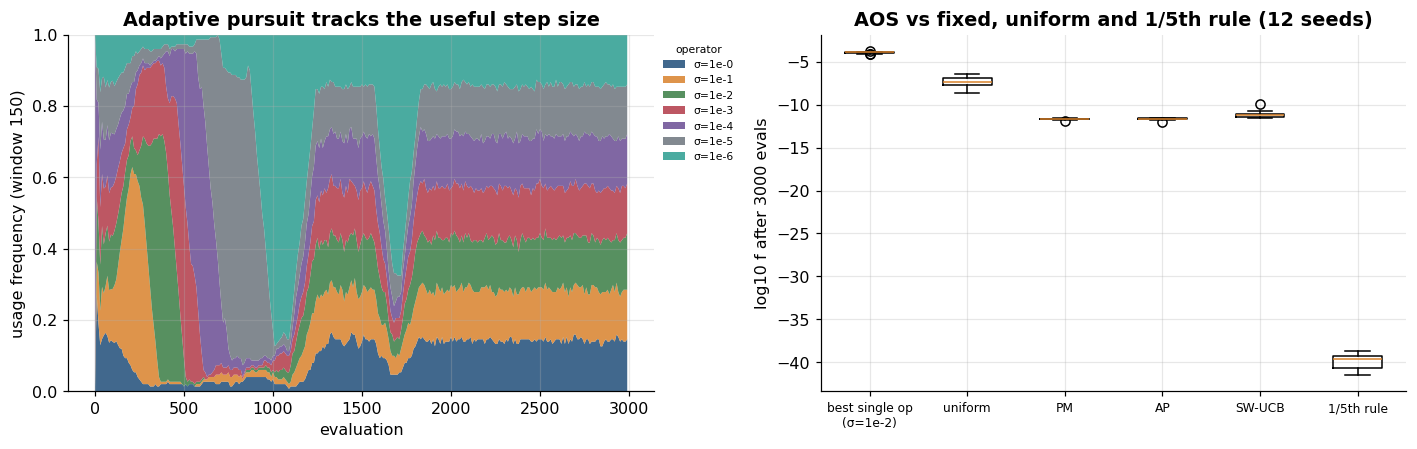

In [7]:
_, used = es_with_aos(AdaptivePursuit(7, np.random.default_rng(0)), B_aos, 0, record=True)
win = 150
freq = np.array([np.bincount(used[max(0, t - win):t + 1], minlength=7) / min(t + 1, win + 1) for t in range(0, len(used), 10)])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].stackplot(np.arange(0, len(used), 10), freq.T, labels=[f"σ=1e-{k}" for k in range(7)], alpha=0.85)
axes[0].set(xlabel="evaluation", ylabel="usage frequency (window 150)", title="Adaptive pursuit tracks the useful step size", ylim=(0, 1))
axes[0].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0), title="operator", title_fontsize=7)
keys = list(aos_res)
axes[1].boxplot([aos_res[k] for k in keys], tick_labels=[k.replace(" (σ=1e-2)", "\n(σ=1e-2)") for k in keys])
axes[1].set(ylabel="log10 f after 3000 evals", title="AOS vs fixed, uniform and 1/5th rule (12 seeds)")
axes[1].tick_params(axis="x", labelsize=8)
plt.tight_layout(); savefig("w6_aos_step_sizes.png"); plt.show()

**Interpretation.** Bandit-based AOS reaches the precision floor set by the smallest operator in the set, orders of
magnitude below uniform selection and any single operator. The left panel shows the tracking: usage moves from
$\sigma=10^{-1}$ to $10^{-2},10^{-3},\dots$ as the distance shrinks. Once even $\sigma=10^{-6}$ is too large
(normalised step $\sigma d/R$ beyond the progress region, $R\approx10^{-6}$), no operator earns credit any more, all
qualities decay towards zero and AP's allocation wanders — there is nothing left to learn. The 1/5th rule, which adapts a *continuous* parameter,
is not limited by a finite operator set at all: when the operators are merely *different values of one parameter*,
parameter control beats operator selection. AOS earns its keep when the operators are **qualitatively** different
(crossover types, local-search moves), which is the setting of hyper-heuristics (§5).

## 4. Offline tuning by racing: F-Race

**Tuning problem.** Given a configuration space $\Theta$, an instance distribution $\mathcal{I}$ and a cost $c(\theta,i)$
(e.g. final error after a fixed budget), find $\arg\min_\theta\mathbb{E}_{i\sim\mathcal{I}}[c(\theta,i)]$ with as few
runs as possible. **Racing** (Maron & Moore 1994; F-Race, Birattari, Stützle, Paquete & Varrentrapp 2002) evaluates
all surviving candidates on one new instance at a time and discards those that are *statistically* worse.
F-Race uses the **Friedman test**: rank the candidates within each instance (block), sum ranks $R_j$ over the $n$
blocks; with $k$ candidates

$$
\chi^2_F = \frac{\frac{12}{nk(k+1)}\sum_{j=1}^{k}R_j^2 - 3n(k+1)}{1-\frac{\sum_{\text{blocks}}\sum_{\text{ties}}(t^3-t)}{nk(k^2-1)}} \;\sim\; \chi^2_{k-1}\ \text{under}\ H_0.
$$

If $H_0$ is rejected, candidate $j$ is discarded when (Conover 1999) $R_j - R_{\text{best}} \gt t_{1-\alpha/2,(n-1)(k-1)}\sqrt{\frac{2(nA_1-\sum_j R_j^2)}{(n-1)(k-1)}}$,
$A_1=\sum_{i,j}r_{ij}^2$. Ranking per instance makes costs on instances of very different scale commensurable.

```text
F-RACE(candidates, instance stream, n_min, alpha):
    alive <- all candidates
    for i = 1, 2, ...:
        run every alive candidate on instance i
        if i >= n_min and Friedman test on the alive columns rejects at level alpha:
            drop every candidate whose rank sum exceeds the best by more than the Conover critical difference
        if |alive| = 1 or budget exhausted: stop
    return the alive candidate with the best mean rank
```

In [8]:
def average_ranks(row):
    """Ranks 1..k with ties receiving the average rank (own implementation)."""
    order = np.argsort(row, kind="mergesort"); ranks = np.empty(len(row)); sr = row[order]
    i = 0
    while i < len(row):
        j = i
        while j + 1 < len(row) and sr[j + 1] == sr[i]: j += 1
        ranks[order[i:j + 1]] = 0.5 * (i + j) + 1; i = j + 1
    return ranks

def friedman_test(Y):
    """Y: (n blocks, k treatments). Returns (chi2 statistic with tie correction, p-value, rank matrix)."""
    n, k = Y.shape
    Rm = np.array([average_ranks(r) for r in Y]); Rj = Rm.sum(0)
    chi2 = 12.0 / (n * k * (k + 1)) * np.sum(Rj**2) - 3.0 * n * (k + 1)
    ties = sum(np.sum(c**3 - c) for c in (np.unique(r, return_counts=True)[1] for r in Y))
    chi2 /= 1.0 - ties / (n * k * (k**2 - 1))
    return chi2, stats.chi2.sf(chi2, k - 1), Rm

# validation against scipy on data with ties
for seed in range(3):
    Yt = np.round(np.random.default_rng(seed).normal(np.arange(6) * 0.3, 1.0, (12, 6)), 0)
    ours = friedman_test(Yt)[:2]; ref = stats.friedmanchisquare(*Yt.T)
    check_close(ours, [ref.statistic, ref.pvalue], f"Friedman chi2 and p vs scipy (seed {seed}, with ties)")
check_close(average_ranks(np.array([3.0, 1.0, 3.0, 2.0])), stats.rankdata([3.0, 1.0, 3.0, 2.0]), "average ranks with ties vs scipy.rankdata")

def conover_critical(Rm, alpha):
    n, k = Rm.shape
    A1, Rj = np.sum(Rm**2), Rm.sum(0)
    return stats.t.ppf(1 - alpha / 2, (n - 1) * (k - 1)) * np.sqrt(2 * (n * A1 - np.sum(Rj**2)) / ((n - 1) * (k - 1)))

def f_race(n_candidates, n_instances, run, n_min=5, alpha=0.05):
    alive, Y, n_runs, trace = list(range(n_candidates)), [], 0, []
    for i in range(n_instances):
        row = np.full(n_candidates, np.nan)
        for c in alive:
            row[c] = run(c, i); n_runs += 1
        Y.append(row)
        if i + 1 >= n_min and len(alive) > 1:
            sub = np.array(Y)[:, alive]
            _, p, Rm = friedman_test(sub)
            if p < alpha:
                Rj = Rm.sum(0); crit = conover_critical(Rm, alpha)
                alive = [c for c, r in zip(alive, Rj) if r - Rj.min() <= crit]
        trace.append((i + 1, len(alive), n_runs))
        if len(alive) == 1: break
    sub = np.array(Y)[:, alive]
    best = alive[int(np.argmin(np.array([average_ranks(r) for r in sub]).mean(0)))]
    return best, alive, n_runs, np.array(trace)

[PASS] Friedman chi2 and p vs scipy (seed 0, with ties): got [2.0243243e+01 1.1250000e-03], expected [2.0243243e+01 1.1250000e-03]
[PASS] Friedman chi2 and p vs scipy (seed 1, with ties): got [2.4549296e+01 1.7000000e-04], expected [2.4549296e+01 1.7000000e-04]
[PASS] Friedman chi2 and p vs scipy (seed 2, with ties): got [2.1193029e+01 7.4500000e-04], expected [2.1193029e+01 7.4500000e-04]
[PASS] average ranks with ties vs scipy.rankdata: got [3.5 1.  3.5 2. ], expected [3.5 1.  3.5 2. ]


**Tuning task.** DE/rand/1/bin with $F\in\lbrace0.2,0.5,0.8,1.0\rbrace\times CR\in\lbrace0,0.3,0.7,1.0\rbrace$ (16 candidates),
$N=20$, 1500 evaluations in $d=5$. Instances: random shifts and rotations of three *different* functions (ellipsoid with
condition $10^3$, Rastrigin, Ackley) in random order — a heterogeneous instance distribution, typical of real tuning.
Ground truth: the full $16\times60$ experiment ("brute force"); the race sees the same instances in the same order.

In [9]:
# ---------------------------------------------------------------------------
# Ask-tell core: every algorithm is (memory M, ask = sample from P(.|M),
# tell = selection/acceptance + memory update). One generic loop drives all.
# ---------------------------------------------------------------------------
from utils import BudgetedObjective, BudgetExhausted


class AskTell:
    """Base class. Subclasses keep their memory in attributes and implement
    ask() -> (n, d) candidates and tell(X, y) -> None.
    `working_fitness()` returns the fitness values of the current working set
    (the states the next generation is derived from), used for diagnostics."""
    name = "base"

    def __init__(self, d, lo, hi, budget, rng):
        self.d, self.lo, self.hi, self.budget, self.rng = d, lo, hi, budget, rng
        self.span = (hi - lo) if lo is not None else 1.0
        self.n_told = 0

    def clip(self, X):
        return X if self.lo is None else np.clip(X, self.lo, self.hi)

    def uniform(self, n):
        return self.rng.uniform(self.lo, self.hi, (n, self.d))

    def progress(self):
        return min(1.0, self.n_told / self.budget)

    def working_fitness(self):
        return np.array([np.nan])


def distinct_indices(rng, n, k, n_pool=None, exclude=None):
    """For each row i < n: k distinct indices from range(n_pool), all different from i
    (and from exclude[i] if given), in uniformly random order (argsort of random keys)."""
    n_pool = n if n_pool is None else n_pool
    keys = rng.random((n, n_pool))
    keys[np.arange(n), np.arange(n)] = np.inf
    if exclude is not None:
        keys[np.arange(n), exclude] = np.inf
    return np.argsort(keys, axis=1)[:, :k]


def optimize(opt, f, budget, callback=None):
    """The single generic loop: ask -> evaluate (counted) -> tell.
    A final batch that would overrun the budget is truncated, so every
    algorithm spends exactly `budget` evaluations."""
    obj = BudgetedObjective(f, budget)
    while obj.remaining > 0:
        X = opt.ask()
        if len(X) > obj.remaining:
            obj(X[: obj.remaining])
            break
        y = obj(X)
        opt.tell(X, y)
        opt.n_told += len(y)
        if callback is not None:
            callback(opt, X, y, obj)
    return obj

class DE(AskTell):
    """DE/rand/1/bin (Storn & Price 1997) with one-to-one greedy replacement."""
    name = "DE"

    def __init__(self, d, lo, hi, budget, rng, n=50, F=0.5, CR=0.9):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.F, self.CR = n, F, CR
        self.P, self.fP = None, None

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d = self.n, self.d
        idx = distinct_indices(self.rng, n, 3)
        V = self.P[idx[:, 0]] + self.F * (self.P[idx[:, 1]] - self.P[idx[:, 2]])
        mask = self.rng.random((n, d)) < self.CR
        mask[np.arange(n), self.rng.integers(0, d, n)] = True
        self.mask = mask
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        imp = y <= self.fP
        self.P[imp], self.fP[imp] = X[imp], y[imp]

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

d_t, n_inst, B_t = 5, 60, 1500
cands = [(F, CR) for F in [0.2, 0.5, 0.8, 1.0] for CR in [0.0, 0.3, 0.7, 1.0]]
ir = np.random.default_rng(2024)
instances = []
for i in range(n_inst):
    kind = ["ellipsoid", "rastrigin", "ackley"][i % 3]
    b = BENCHMARKS[kind]
    base = (lambda X: ellipsoid(X, 1e3)) if kind == "ellipsoid" else b.f
    instances.append((shifted_rotated(base, ir.uniform(0.5 * b.lower, 0.5 * b.upper, d_t), random_rotation(d_t, ir)), b.lower, b.upper))
order = ir.permutation(n_inst); instances = [instances[j] for j in order]

cache = {}
def run_config(c, i):
    if (c, i) not in cache:
        f, lo, hi = instances[i]; F, CR = cands[c]
        cache[c, i] = optimize(DE(d_t, lo, hi, B_t, np.random.default_rng(1000 * i + 7), n=20, F=F, CR=CR), f, B_t).best_f
    return cache[c, i]

best_race, alive_race, runs_race, trace = f_race(len(cands), n_inst, run_config)
full = np.array([[run_config(c, i) for c in range(len(cands))] for i in range(n_inst)])
chi2_full, p_full, Rm_full = friedman_test(full)
mean_rank = Rm_full.mean(0)
crit_full = conover_critical(Rm_full, 0.05)
not_worse = np.flatnonzero(Rm_full.sum(0) - Rm_full.sum(0).min() <= crit_full)
print(f"brute force: {full.size} runs, Friedman chi2 = {chi2_full:.1f} (p = {p_full:.1e}); best (F, CR) = {cands[np.argmin(mean_rank)]}, "
      f"mean rank {mean_rank.min():.2f}; statistically tied with best: {[cands[j] for j in not_worse]}")
print(f"F-Race: {runs_race} runs ({runs_race / full.size:.0%} of brute force), survivors {[cands[j] for j in alive_race]}, "
      f"chosen {cands[best_race]} (full-data mean rank {mean_rank[best_race]:.2f})")
check_true(best_race in not_worse, "the race winner is not significantly worse than the brute-force best")
check_true(runs_race < 0.5 * full.size, "racing used less than half of the brute-force runs")

brute force: 960 runs, Friedman chi2 = 360.7 (p = 1.2e-67); best (F, CR) = (0.5, 0.7), mean rank 3.58; statistically tied with best: [(0.2, 0.3), (0.5, 0.7), (0.5, 1.0)]
F-Race: 303 runs (32% of brute force), survivors [(0.2, 0.3), (0.5, 0.7), (0.5, 1.0)], chosen (0.5, 0.7) (full-data mean rank 3.58)
[PASS] the race winner is not significantly worse than the brute-force best
[PASS] racing used less than half of the brute-force runs


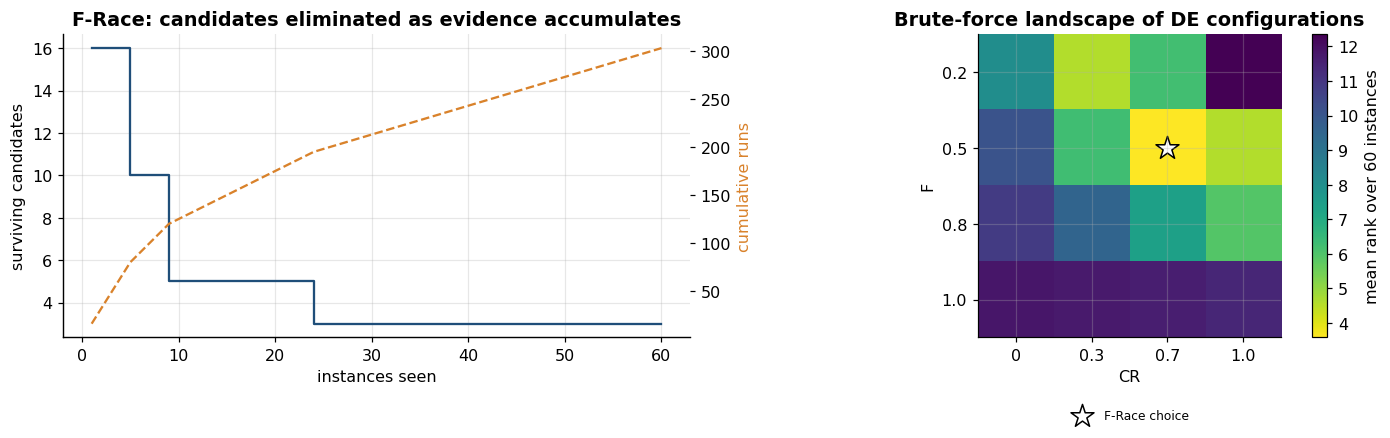

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].step(trace[:, 0], trace[:, 1], where="post", color=PALETTE["blue"])
axes[0].set(xlabel="instances seen", ylabel="surviving candidates", title="F-Race: candidates eliminated as evidence accumulates")
ax2 = axes[0].twinx(); ax2.plot(trace[:, 0], trace[:, 2], color=PALETTE["orange"], ls="--"); ax2.set_ylabel("cumulative runs", color=PALETTE["orange"]); ax2.grid(False)
M = mean_rank.reshape(4, 4)
im = axes[1].imshow(M, cmap="viridis_r"); plt.colorbar(im, ax=axes[1], label="mean rank over 60 instances")
axes[1].set(xticks=range(4), xticklabels=[0, 0.3, 0.7, 1.0], yticks=range(4), yticklabels=[0.2, 0.5, 0.8, 1.0],
            xlabel="CR", ylabel="F", title="Brute-force landscape of DE configurations")
fb, cb = divmod(best_race, 4); axes[1].scatter([cb], [fb], marker="*", s=250, color="white", edgecolor="k", label="F-Race choice")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=8, frameon=False)
plt.tight_layout(); savefig("w6_frace.png"); plt.show()

**Iterated racing (irace; López-Ibáñez, Dubois-Lacoste, Pérez Cáceres, Birattari & Stützle 2016).** F-Race needs a finite
candidate list. irace wraps it in an estimation-of-distribution loop: sample configurations from per-parameter
distributions (truncated normals for numeric, categorical for discrete parameters), race them, and move the sampling
distributions towards the elite survivors — i.e. *a metaheuristic tuning a metaheuristic*. ParamILS (Hutter et al. 2009)
uses iterated local search in configuration space; SMAC (Hutter, Hoos & Leyton-Brown 2011) uses a random-forest
surrogate with Bayesian optimisation.

**AI/ML connection.** Algorithm configuration *is* hyperparameter optimisation (HPO): racing is closely related to
successive halving and Hyperband (Jamieson & Talwalkar 2016; Li et al. 2017), which also discard poor configurations
early, but on partial *training budgets* instead of instances; Bayesian optimisation (Snoek, Larochelle & Adams 2012)
replaces racing by a surrogate model; population-based training (Jaderberg et al. 2017) is self-adaptive parameter
control for neural-network training.

## 5. Selection hyper-heuristics for one-dimensional bin packing

A **hyper-heuristic** searches the space of *heuristics* rather than solutions (Burke et al. 2013, *JORS* 64). A
*selection perturbative* hyper-heuristic keeps a solution and repeatedly (i) chooses a low-level heuristic (LLH) with a
selection rule, (ii) applies it, (iii) accepts or rejects the result with a move-acceptance rule; it sees only the
objective value, never the problem structure — the "domain barrier".

**Problem.** Items $w_i$, capacity $C=1000$; a solution is a permutation decoded by *first fit*; objective
$N_{\text{bins}} + 1 - \frac{1}{N_{\text{bins}}}\sum_b (F_b/C)^2$ (bin count, tie-broken by Falkenauer's fill measure, so
fuller bins are rewarded). Lower bound $L_1=\lceil\sum w_i/C\rceil$. Two instance classes: **triplets** (Falkenauer
1996: every bin of an optimal solution holds exactly three items that fill it, so $\text{OPT}=L_1$) and **uniform**
items in $[100,500]$. LLHs: swap two items; move an item to the front; move the items of the least-filled bin to the front;
reverse a segment. Acceptance: improving-or-equal. Selection: each LLH alone, uniform random, AP, SW-UCB.

In [11]:
Cap = 1000

def triplet_instance(K, r):
    items = []
    for _ in range(K):
        a = int(r.integers(380, 491)); b = int(r.integers(250, Cap - a - 250 + 1)); items += [a, b, Cap - a - b]
    r.shuffle(items); return items

def uniform_instance(n, r):
    return [int(v) for v in r.integers(100, 501, n)]

def first_fit(order, w):
    res, bins = [], []
    for i in order:
        wi = w[i]
        for b in range(len(res)):
            if res[b] >= wi:
                res[b] -= wi; bins[b].append(i); break
        else:
            res.append(Cap - wi); bins.append([i])
    return res, bins

def bp_cost(order, w):
    res, bins = first_fit(order, w); N = len(res)
    return N + 1 - sum(((Cap - r) / Cap) ** 2 for r in res) / N, bins, res

LLH_NAMES = ["swap", "to-front", "empty-bin", "reverse"]
def apply_llh(k, order, bins, res, R):
    o = order[:]; n = len(o)
    if k == 0:
        i, j = R.sample(range(n), 2); o[i], o[j] = o[j], o[i]
    elif k == 1:
        i = R.randrange(n); o.insert(0, o.pop(i))
    elif k == 2:
        b = max(range(len(res)), key=res.__getitem__); front = bins[b][:]; R.shuffle(front); s = set(front)
        o = front + [x for x in o if x not in s]
    else:
        i, j = sorted(R.sample(range(n + 1), 2)); o[i:j] = o[i:j][::-1]
    return o

def hyper_heuristic(w, selector, budget, seed):
    R = random.Random(seed)
    order = list(range(len(w))); R.shuffle(order)
    fx, bins, res = bp_cost(order, w); counts = np.zeros(4)
    for _ in range(budget - 1):
        k = selector.select(); counts[k] += 1
        o = apply_llh(k, order, bins, res, R); fy, b2, r2 = bp_cost(o, w)
        selector.update(k, max(0.0, fx - fy))
        if fy <= fx: order, fx, bins, res = o, fy, b2, r2
    return fx, counts

# independent checks on the instance generator and a classical bound
for s in range(3):
    w = triplet_instance(20, np.random.default_rng(100 + s))
    check_true(sum(w) == 20 * Cap and all(250 <= x <= 500 for x in w), f"triplet instance {s}: sum = 20 C, items in [250, 500] => OPT = L1 = 20")
    ffd = len(first_fit(list(np.argsort(w)[::-1]), w)[0])
    check_true(20 <= ffd <= 11 / 9 * 20 + 6 / 9, f"first-fit decreasing uses {ffd} bins <= 11/9 OPT + 6/9 (Dósa 2007)")

[PASS] triplet instance 0: sum = 20 C, items in [250, 500] => OPT = L1 = 20
[PASS] first-fit decreasing uses 24 bins <= 11/9 OPT + 6/9 (Dósa 2007)
[PASS] triplet instance 1: sum = 20 C, items in [250, 500] => OPT = L1 = 20
[PASS] first-fit decreasing uses 24 bins <= 11/9 OPT + 6/9 (Dósa 2007)
[PASS] triplet instance 2: sum = 20 C, items in [250, 500] => OPT = L1 = 20
[PASS] first-fit decreasing uses 24 bins <= 11/9 OPT + 6/9 (Dósa 2007)


In [12]:
B_hh, seeds_hh = 2000, 8
methods = {**{f"only {n}": (lambda r, k=k: FixedOp(4, r, k)) for k, n in enumerate(LLH_NAMES)},
           "uniform": lambda r: UniformOp(4, r), "AP": lambda r: AdaptivePursuit(4, r, p_min=0.05),
           "SW-UCB": lambda r: SlidingWindowUCB(4, r)}
hh_res, hh_usage = {}, {}
for cls in ["triplets", "uniform"]:
    for m, mk in methods.items():
        vals, use = [], []
        for s in range(seeds_hh):
            ir = np.random.default_rng(100 + s)
            w = triplet_instance(20, ir) if cls == "triplets" else uniform_instance(60, ir)
            L1 = -(-sum(w) // Cap)
            fx, counts = hyper_heuristic(w, mk(np.random.default_rng(s)), B_hh, s)
            vals.append(fx - L1); use.append(counts / counts.sum())
        hh_res[cls, m], hh_usage[cls, m] = np.array(vals), np.mean(use, 0)
for cls in ["triplets", "uniform"]:
    print(f"{cls}: objective minus L1 (integer part = extra bins), median over {seeds_hh} instances")
    for m in methods:
        print(f"   {m:16s} {np.median(hh_res[cls, m]):.4f}")
    Y = np.array([hh_res[cls, m] for m in methods]).T
    mr = np.array([average_ranks(r) for r in Y]).mean(0)
    names_m = list(methods)
    print("   mean ranks:", dict(zip(names_m, np.round(mr, 2).tolist())))
    worst_single = max(np.median(hh_res[cls, f"only {n}"]) for n in LLH_NAMES)
    best_single = min(np.median(hh_res[cls, f"only {n}"]) for n in LLH_NAMES)
    for m in ["uniform", "AP", "SW-UCB"]:
        check_true(np.median(hh_res[cls, m]) < worst_single and np.median(hh_res[cls, m]) - best_single < 0.02,
                   f"{cls}: {m} is within 0.02 of the best single LLH and better than the worst")
n_solved = sum(int(np.sum(np.floor(hh_res["triplets", m]) == 0)) for m in methods)
print(f"triplet runs (all methods) that reached L1 bins: {n_solved} of {len(methods) * seeds_hh}")
print("AP average LLH usage (triplets):", dict(zip(LLH_NAMES, np.round(hh_usage["triplets", "AP"], 2).tolist())))

triplets: objective minus L1 (integer part = extra bins), median over 8 instances
   only swap        1.0739
   only to-front    2.1609
   only empty-bin   2.1680
   only reverse     1.0818
   uniform          1.0757
   AP               1.0685
   SW-UCB           1.0789
   mean ranks: {'only swap': 2.5, 'only to-front': 6.06, 'only empty-bin': 6.94, 'only reverse': 4.38, 'uniform': 3.0, 'AP': 1.62, 'SW-UCB': 3.5}
[PASS] triplets: uniform is within 0.02 of the best single LLH and better than the worst
[PASS] triplets: AP is within 0.02 of the best single LLH and better than the worst
[PASS] triplets: SW-UCB is within 0.02 of the best single LLH and better than the worst
uniform: objective minus L1 (integer part = extra bins), median over 8 instances
   only swap        0.0593
   only to-front    0.6058
   only empty-bin   1.1286
   only reverse     0.0676
   uniform          0.0623
   AP               0.0596
   SW-UCB           0.0613
   mean ranks: {'only swap': 1.5, 'only to-front': 6

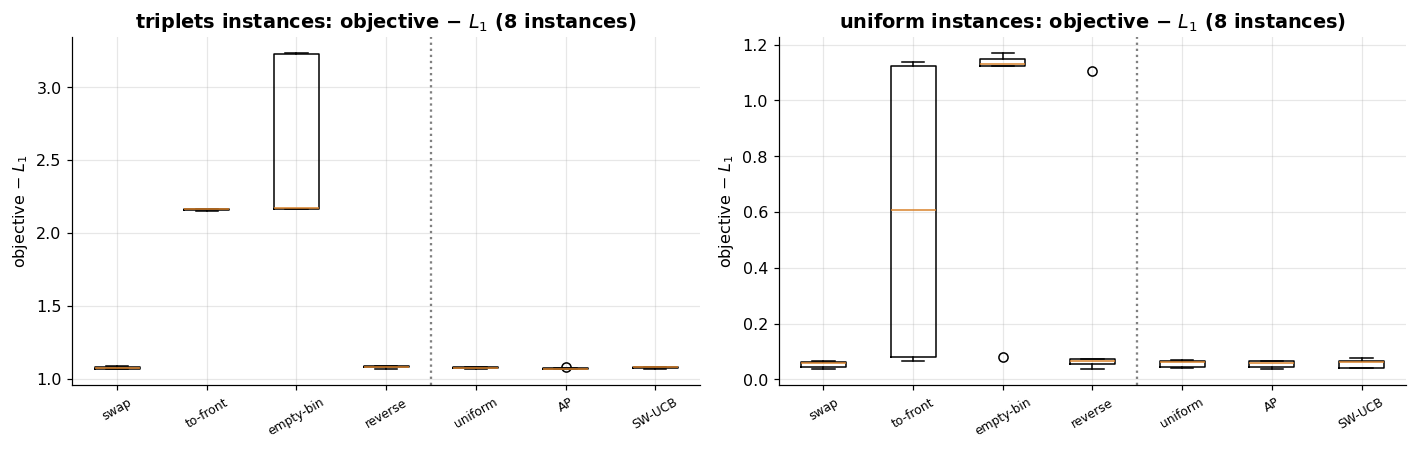

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, cls in zip(axes, ["triplets", "uniform"]):
    ms = list(methods)
    ax.boxplot([hh_res[cls, m] for m in ms], tick_labels=[m.replace("only ", "") for m in ms])
    ax.set(title=f"{cls} instances: objective − $L_1$ (8 instances)", ylabel="objective − $L_1$")
    ax.axvline(4.5, color="grey", ls=":")
    ax.tick_params(axis="x", labelsize=8, rotation=30)
plt.tight_layout(); savefig("w6_hyper_heuristic_binpacking.png"); plt.show()

**Interpretation.** Two LLHs (to-front, empty-bin) are poor *on their own* here, and which LLH is best is not known
in advance. The hyper-heuristics match the best single LLH without being told which one it is, and are far from
the poor ones: the value of selection hyper-heuristics is **robustness across instance classes**, not beating the best
specialist. AP puts the largest share of its budget (about 60 %) on the best LLH (swap); the others keep 11–17 % — well
above the $p_{\min}=0.05$ floor — because the arm with the highest recent quality changes repeatedly during a run.
With only improving-or-equal acceptance, no method packs a triplet instance into $L_1$ bins within 2000
evaluations (all end one bin above, see the printed count) — the acceptance rule (e.g. late acceptance, simulated-annealing acceptance) is the other half of a
hyper-heuristic design.

## Key takeaways
- **Tuning** fixes parameters offline; **control** changes them online — deterministically (schedules), adaptively
  (external feedback rules) or self-adaptively (parameters inside the genome).
- Self-adaptive log-normal step sizes are unbiased on the log scale, keep $\sigma^{\ast}$ in the progress region and make
  the ES scale invariant; deterministic schedules only work at the scale they were tuned for; constant $\sigma$ stalls at
  $R_\infty=\sigma d/(2c_{1,\lambda})$.
- AOS = non-stationary bandits: PM, AP and (sliding-window) UCB follow their stationary laws and track the best
  operator; when operators are values of one continuous parameter, continuous control is better still.
- Racing (F-Race) finds a configuration statistically indistinguishable from the brute-force best at a fraction of the
  cost; ranking per instance makes heterogeneous instances comparable.
- Selection hyper-heuristics buy robustness: they approach the best low-level heuristic without knowing it.

## Exercises
1. ★ Show that the log-normal rule satisfies $\mathbb{E}[\ln\sigma']=\ln\sigma$ and $\mathbb{E}[\sigma']=\sigma e^{\tau^2/2}$.
   Why is additive Gaussian mutation of $\sigma$ a poor alternative?
2. ★★ Derive $c_{1,\lambda}=\int x\,\lambda\,\phi(x)\Phi(x)^{\lambda-1}dx$ and the stationary distance
   $R_\infty=\sigma d/(2c_{1,\lambda})$ of the $(1,\lambda)$-ES with constant $\sigma$ from $\varphi^{\ast}=c_{1,\lambda}\sigma^{\ast}-\sigma^{\ast2}/2$.
3. ★★ Prove that adaptive pursuit in a stationary environment with a unique best arm converges to $p_{\max}$ for that
   arm, and give the convergence rate in terms of $\beta$.
4. ★★ Replace the Friedman/Conover elimination in `f_race` by pairwise Wilcoxon signed-rank tests with Holm
   correction. Compare the number of runs and the chosen configuration on the DE tuning task.
5. ★★★ Implement a miniature irace: sample 16 $(F,CR)$ from truncated normals, race them, re-centre the distributions on
   the survivors, repeat for 4 iterations. Compare the final configuration with the grid race at the same number of runs.
6. ★★★ Add simulated-annealing move acceptance and late acceptance (Burke & Bykov 2017) to the hyper-heuristic. Which
   combination of selection and acceptance solves the most triplet instances to $L_1$ with 5000 evaluations?